# Running ECMWF AIFS on Any Machine

**ECMWF's AIFS** (Artificial Intelligence Forecast System) is a state-of-the-art
ML weather model — but its official implementation requires **Ampere-class NVIDIA GPUs**
and the `flash-attn` library, which is painful to install.

This notebook shows how to run AIFS on:

| Hardware | What happens |
|---|---|
| **NVIDIA Ampere / Ada (A100, H100, RTX 3090+)** | Full speed, best performance |
| **Older NVIDIA (V100, T4, RTX 20xx)** | Works via PyTorch SDPA fallback |
| **Apple Silicon (M1/M2/M3)** | Runs via Metal (MPS) — chunked attention |
| **CPU only** | Works but slow; fine for testing |

---
**What you'll need**
- Python ≥ 3.10
- The packages in `requirements.txt`
- ~1–2 GB disk space for the IC cache
- Internet access (to download ECMWF Open Data)


## 1. Installation

```bash
git clone https://huggingface.co/datasets/YOUR_USERNAME/aifs-tutorial
cd aifs-tutorial
pip install -r requirements.txt
```

> **Note on `flash-attn`**: you do **not** need to install it.
> This repo ships a pure-PyTorch shim that replaces it automatically.


## 2. Check your device


In [1]:
from aifs.device import get_device, device_label

print("Active device :", device_label())
print("Device string :", get_device())  # 'cuda' | 'mps' | 'cpu'


Active device : Apple MPS (Metal)
Device string : mps


## 3. Download initial conditions

AIFS uses **two consecutive 6-hour analysis fields** (t-6h and t) as input.
We pull them from [ECMWF Open Data](https://www.ecmwf.int/en/forecasts/datasets/open-data),
which is freely available without registration.

The download takes ~3–5 minutes on a fast connection.
Subsequent runs load from a local `.npz` cache faster (in seconds).


In [2]:
from aifs.initial_conditions import load_ics

fields, date = load_ics(variant="single", cache_dir="ic_cache")

print(f"\nInitialisation date : {date}")
print(f"Number of fields    : {len(fields)}")
print(f"Example field shape : {list(fields.values())[0].shape}")


To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


📅  Latest ECMWF run : 2026-07-02 00:00:00
🤖  Model variant    : single
⬇️   Downloading initial conditions …
  ⬇  Surface fields …


<multiple>:   0%|          | 0.00/7.37M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


<multiple>:   0%|          | 0.00/7.45M [00:00<?, ?B/s]

...

<multiple>:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

  ⬇  Pressure-level fields …


<multiple>:   0%|          | 0.00/40.8M [00:00<?, ?B/s]

<multiple>:   0%|          | 0.00/40.5M [00:00<?, ?B/s]

💾  Saved to ic_cache/ic_single_20260702T000000.npz  (653 MB)

Initialisation date : 2026-07-02 00:00:00
Number of fields    : 97
Example field shape : (2, 542080)


## 4.  Run a forecast

`lead_time` must be a multiple of 6 hours.
Each step takes ~20–60 s on a modern GPU, ~5–15 min on CPU.

**Memory guidance for `num_chunks`**:
The highest `num_chunks` is, the least memory is used. The inference will be slightly slower (16 is a good start, change to 32 or 64 if running into RAM issues).


In [3]:
from aifs.forecast import run_forecast

states = run_forecast(
    fields=fields,
    date=date,
    lead_time=12,
    num_chunks=16,
    checkpoint="aifs-single-2.0"
)

print(f"\nOutput steps : {len(states)}")
for s in states:
    print(f"  {s['date']}")

🖥️   Device  : Apple MPS (Metal) 

 Checkpoint: aifs-single-2.0 

 Lead time : 12 h  (2 steps)
🤖  Loading model …


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

The metadata file 'ai-models.json' is deprecated. New versions of checkpoints will write to 'anemoi.json' instead.
[data] Constant forcings are not supported by this runner.
[data] ['lsm', 'sdor', 'slor', 'wmb', 'z'] must be provided in the input state by the user.
NaNs found in the following variables: ['cdww', 'cos_mwd', 'h1012', 'h1214', 'h1417', 'h1721', 'h2125', 'h2530', 'mwp', 'sin_mwd', 'swh', 'wmb']


🌍  Running inference …
  [compat] attn 0.30s  device=mps  ws=1120
  [compat] attn 0.42s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
    ✓  2026-07-02 06:00:00
✅  Done — 1 steps produced.
  [compat] attn 0.31s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.4

## 5.  Inspect raw output

Each `state` is a plain dict.  The fields live under `state["fields"]`.


In [4]:
step = states[0]
t2m  = step["fields"]["2t"]              # 2-m temperature

print("Step date      :", step["date"])
print("Field keys     :", list(step["fields"].keys())[:10], "…")
print("2t shape       :", t2m.shape)
print(f"2t range       : {t2m.min():.1f} – {t2m.max():.1f} K")
print(f"2t global mean : {t2m.mean():.2f} K  ({t2m.mean() - 273.15:.2f} °C)")


Step date      : 2026-07-02 06:00:00
Field keys     : ['100u', '100v', '10u', '10v', '2d', '2t', 'cdww', 'cos_mwd', 'cp', 'h1012'] …
2t shape       : (542080,)
2t range       : 200.2 – 319.8 K
2t global mean : 289.84 K  (16.69 °C)


## 6. Plot a single field

In [ ]:
from aifs.plot import plot_field

fig = plot_field(states[-1], "2t")
fig.savefig("t2m.png", dpi=150, bbox_inches="tight")

### Try other variables:

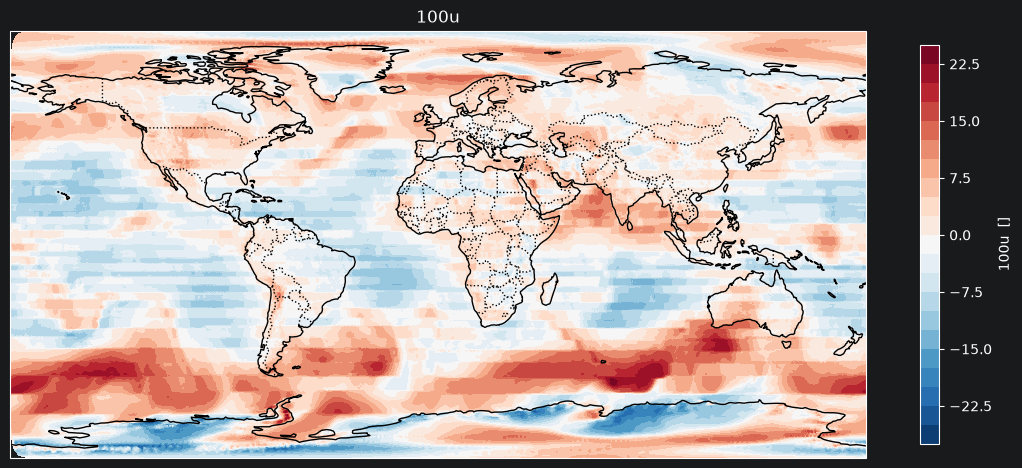

In [7]:
fig = plot_field(states[-1], "100u")
fig.savefig("t2m.png", dpi=150, bbox_inches="tight")

## 7 — Streaming forecast (for long runs / GUIs)

Use `run_forecast_streaming` to process each step as it arrives instead of waiting for the full run to complete.


In [11]:
from aifs.forecast import run_forecast_streaming

for state in run_forecast_streaming(fields, date, lead_time=24):
    t2m_mean = state["fields"]["2t"].mean() - 273.15
    print(f"  {state['date']}  |  global mean T2m = {t2m_mean:.2f} °C")


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

The metadata file 'ai-models.json' is deprecated. New versions of checkpoints will write to 'anemoi.json' instead.
[data] Constant forcings are not supported by this runner.
[data] ['lsm', 'sdor', 'slor', 'wmb', 'z'] must be provided in the input state by the user.
NaNs found in the following variables: ['cdww', 'cos_mwd', 'h1012', 'h1214', 'h1417', 'h1721', 'h2125', 'h2530', 'mwp', 'sin_mwd', 'swh', 'wmb']


  [compat] attn 0.32s  device=mps  ws=1120
  [compat] attn 0.44s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.42s  device=mps  ws=1120
  [compat] attn 0.43s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.42s  device=mps  ws=1120
  [compat] attn 0.43s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.42s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
    ✓  2026-06-30 12:00:00
  2026-06-30 12:00:00  |  global mean T2m = 17.12 °C
  [compat] attn 0.31s  device=mps  ws=1120
  [compat] attn 0.43s  device=mps  ws=1120
  [compat] attn 0.43s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0

## 9. Saving & reloading forecast output

Forecast states are plain Python dicts with NumPy arrays — save them however you like.


## 10 — Next steps

- **Longer forecasts**: change `lead_time` to 72, 120, 240 hours
- **Regional zoom**: use Cartopy's `set_extent` on the returned figure's axes
- **NetCDF export**: regrid from N320 back to a lat/lon grid with `earthkit-regrid`
  then write with `xarray` + `netCDF4`
- **Gradio demo**: see `app.py` in this repo for a browser-based interface
- **AIFS Ensemble**: swap the checkpoint for `ecmwf/aifs-ens-1.0`

Questions / issues?  Open an issue on the HuggingFace repo.
